<a id="1"></a> 
### Information about the dataset:
This is the sentiment140 dataset. It contains 1,600,000 tweets extracted using the twitter api . The tweets have been annotated (0 = negative, 4 = positive) and they can be used to detect sentiment

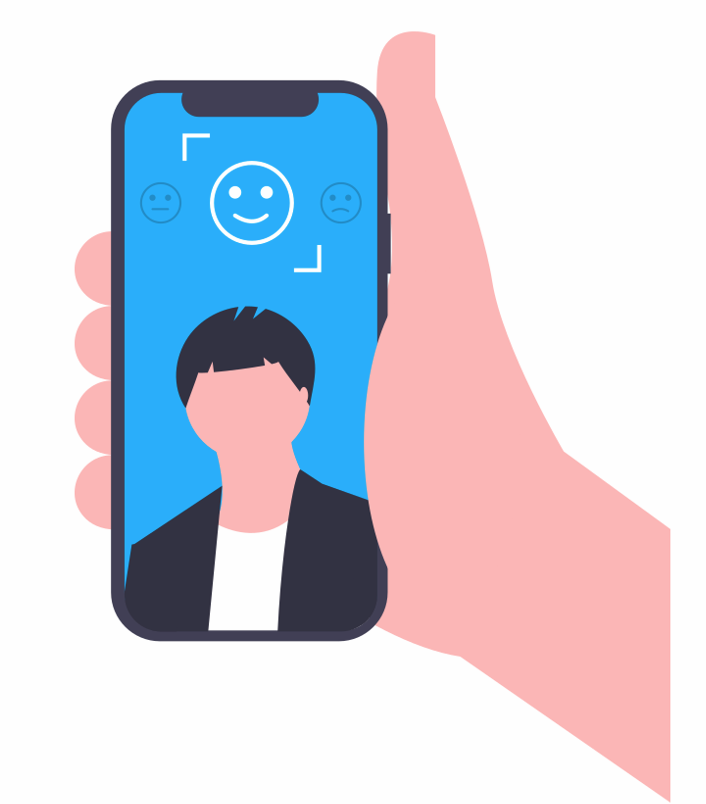

> **Table of Contents:**
> * [Information about the dataset](#1)
> * [Importing Libraries](#2)
> * [Loading Data](#3)
> * [EDA - Exploratory Data Analysis](#4)
> * [PreProcessing](#5)
> * [The Tokenizer and Padding](#6)
> * [Model and Predictions](#7)
> ---

<a id="2"></a> 
# 1. Importing Libraries 📚

In [ ]:
import pandas as pd
import numpy as np
import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import nltk
import re
import multiprocessing
import tensorflow as tf
from sklearn.model_selection import train_test_split
nltk.download("stopwords")

import warnings
warnings.filterwarnings("ignore")

<a id="3"></a> 
# 2. Loading the Data 💬

In [ ]:
# setting the names of the columns into col_names

col_names = ["target", "ids", "date", "flag", "user", "text"]
# reading the data from the path and using ISO-8859-1 encoding to decode it.

df = pd.read_csv('../input/sentiment140/training.1600000.processed.noemoticon.csv',
            encoding = "ISO-8859-1",
            names=col_names)

In [ ]:
df = df.sample(160000) # taking 160k rows from the data
df.head()

<a id="4"></a> 
# 3. Let's Explore 👓 -


In [ ]:
df.info() # shows the columns, and their types.

In [ ]:
df.shape

In [ ]:
df.describe(include='all') # To statistical measures of the columns

In [ ]:
sns.countplot(x=df['target']); # shows a count plot refering to the number of 0 and 4 in the column

In [ ]:
df = df.drop(['ids', 'date', 'flag','user'], axis = 1) # dropping unnecessary columns

In [ ]:
df.head()

<a id="5"></a> 
# 4. Preprocessing  🤠

Here 0 represents as negative and 4 as positive so lets change 4 to 1.

In [ ]:
df['target']=df['target'].replace(4,1) 

In [ ]:
data = df['text']
labels = np.array(df['target'])

In [ ]:
data.iloc[1] # displaying a row of the data

### 4.B. Stopwords removal

In [ ]:
# this function is copied from another kernel. Don't know who is the original author of it.
stop = set(stopwords.words('english'))
punctuation = list(string.punctuation)
stop.update(punctuation)

#Removing the stopwords from text
def split_into_words(text):
    # split into words by white space
    words = text.split()
    return words

def to_lower_case(words):
    # convert to lower case
    words = [word.lower() for word in words]
    return words

def remove_punctuation(words):
    # prepare regex for char filtering
    re_punc = re.compile('[%s]' % re.escape(string.punctuation))
    # remove punctuation from each word
    stripped = [re_punc.sub('', w) for w in words]
    return stripped

def keep_alphabetic(words):
    # remove remaining tokens that are not alphabetic
    words = [word for word in words if word.isalpha()]
    return words

def remove_stopwords(words):
    # filter out stop words
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if not w in stop_words]
    return words

def to_sentence(words):
    # join words to a sentence
    return ' '.join(words)
def tweet(words):
    tweet_tokenizer = nltk.tokenize.TweetTokenizer(strip_handles=True,reduce_len=True)
    tweet = tweet_tokenizer.tokenize(words)
    return tweet
        

#Removing the noisy text
def denoise_text(text):
    words = split_into_words(text)
    words = to_lower_case(words)
    words = remove_punctuation(words)
    words = keep_alphabetic(words)
    words = remove_stopwords(words)
    return to_sentence(words)

In [ ]:
data = data.apply(denoise_text)

To see the difference in before and after applying stopwords function.

In [ ]:
print('Before: {}'. format(list(df['text'][:2])))
print('---')
print('After: {}'. format(list(data[:2])))

In [ ]:
print(f"dataset contains {len(data)} examples\n")

print(f"Text of second example should look like this:  {data.iloc[1]}\n")
print(f"Text of fourth example should look like this:  {data.iloc[3]}")

print(f"\nLabels of last 5 examples should look like this:\n{labels[-5:]}")

# 4.C. Splitting the Data ✂

In [ ]:
# Split in training validation and test sets
X_train, X_test, y_train, y_test = test = train_test_split(data, labels,test_size=0.20,
                                                           random_state=1,
                                                           stratify = labels)

<a id="6"></a> 
# 5. Its "THE TOKENIZER ⚔" 

In [ ]:
# lets take 10k words in num_words
tokenizer = Tokenizer(num_words=10000, oov_token = '<OOV>')
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index
VOCAB_SIZE = len(word_index)+1
VOCAB_SIZE

In [ ]:
maxlen = max([len(x) for x in X_train]) # return 175 which is too big for tweets data.
maxlen = 50

### 5.B. Sequencing and Padding

In [ ]:
train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded_sequences = pad_sequences(train_sequences,maxlen=maxlen,padding='post',truncating='post')
test_sequences = tokenizer.texts_to_sequences(X_test)
test_padded_sequences = pad_sequences(test_sequences,maxlen=maxlen,padding='post',truncating='post')

In [ ]:
len(train_padded_sequences[0])

<a id="7"></a> 
# 5. Data Modeling - Here we go again !!! 👾

In [ ]:
embedding_dim = 32

In [ ]:
model = tf.keras.Sequential([
        tf.keras.layers.Embedding(VOCAB_SIZE+1, embedding_dim, input_length=maxlen),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(embedding_dim,activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(8,activation='relu'),
        tf.keras.layers.Dense(1,activation='sigmoid'),
    ])

model.compile(loss = 'binary_crossentropy',
                optimizer = 'adam',
                metrics = ['accuracy'])

In [ ]:
#summary of the model.
model.summary()

In [ ]:
# Training the model we created above. 
history =    model.fit(train_padded_sequences,
                                               y_train,
                                               validation_data = (test_padded_sequences, y_test),
                                               epochs = 3)

In [ ]:
print(X_test.iloc[99],'label: ;',y_test[99])

In [ ]:
tokenizer.sequences_to_texts(test_padded_sequences)[99]

In [ ]:
model.predict(test_padded_sequences)[99]

In [ ]:
import matplotlib.pyplot as plt

# Plot utility
def plot_graphs(model, string):
  plt.plot(model.history[string])
  plt.plot(model.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()
  
# Plot the accuracy and loss
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

### <center>Thanks for reading:)</center>
### <center>Upvote! and Leave some suggestions</center>
### <center> Check out my [channel](https://www.youtube.com/c/MusaKhanOC)</center>